In [1]:
import numpy as np
import pandas as pd
import os
import re
from functools import partial
from itertools import starmap

from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter
from scipy.ndimage import uniform_filter as unifilt
from scipy import interpolate
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

from iEEG_utils.loading import read_data
from iEEG_utils.processing.filtering import bipolar_reref, zscore
from iEEG_utils.spike_checks import spike_utils
from iEEG_utils import utils

from pymultitaper import spectral

rng = np.random.default_rng()

In [2]:
# use file selection dialog to choose folder with data
fstr = read_data.select_directory()
print(fstr)

# load each data file
montage = read_data.load_info(fstr,ftype="montage")
montage.name = montage.name.replace(" ","",regex=True)
origfs,data = read_data.load_iEEG(fstr,load_meta=True)
events = read_data.load_info(fstr,ftype="events")
data.columns = data.columns.str.replace(r"\s+", "", regex=True)

try:
    origtime = pd.to_datetime(data.time,format='%H:%M:%S.%f')
except AttributeError:
    origtime = pd.to_datetime(data.index,format='%H:%M:%S.%f')
    
origts = np.array(origtime-origtime[0])/ np.timedelta64(1, 's')

if origfs == None:
    origfs = 1/np.diff(origts).astype("float64").mean()
    print("original sampling frequency not declared, calculated as: "+str(origfs)+" Hz")

montage = montage.loc[(montage.keep)&(montage.region!="DC_sync"),:]
display(montage)

# Align traces to image onsets
img_ts = origts[events.img_on_ix]
pairs_list = np.array(utils.find_valid_pairs(montage.loc[:,"name"].to_list(),montage["region"].to_list()))

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\a5a41c\EmotionTask


,ID,age,region,ch,name,keep
1,a5a41c,12,l_amy,2,LA_3,True
2,a5a41c,12,l_amy,3,LA_4,True
10,a5a41c,12,l_inferiortemporal,28,LC_13,True
11,a5a41c,12,l_inferiortemporal,29,LC_14,True
12,a5a41c,12,l_insula,59,LI_2,True
13,a5a41c,12,l_insula,60,LI_3,True
17,a5a41c,12,l_lateralorbitofrontal,104,LO_11,True
18,a5a41c,12,l_lateralorbitofrontal,105,LO_12,True
19,a5a41c,12,l_medialorbitofrontal,111,LP_2,True
20,a5a41c,12,l_medialorbitofrontal,112,LP_3,True


In [3]:
ins = utils.find_valid_pairs(montage.loc[montage.region.str.contains("insula"),"name"].to_list(),
                             montage.loc[montage.region.str.contains("insula"),"region"].to_list())
if len(ins) == 1:
    pair1 = ins[0]
else:
    pair1 = ins[0]
    print(f"choosing {ins[0]}")
lOFC = utils.find_valid_pairs(montage.loc[montage.region.str.contains("lateralorbit"),"name"].to_list(),
                              montage.loc[montage.region.str.contains("lateralorbit"),"region"].to_list())
if len(lOFC) == 1:
    pair2 = lOFC[0]
else:
    pair2 = lOFC[0]
    print(f"choosing {lOFC[0]}")

assert(pair1[0][0]==pair2[0][0])

In [4]:
# parameters for signal processing
resrate = 1024
lpfreq = 300
# time prior to (pre) and after (post) image onset
s_pre = -1.5
s_post = 2.5
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds

# img_cats = ["anger","fear","neutral","happy"]

ts,bipolar1,filtwins1 = bipolar_reref(data.loc[:,pair1[::-1]],origfs,
                                     resrate,lpfreq=lpfreq,norm=None)

ts,bipolar2,filtwins1 = bipolar_reref(data.loc[:,pair2[::-1]],origfs,
                                     resrate,lpfreq=lpfreq,norm=None)


spect_ixs = np.array([np.where((ts>=(im_t+s_pre))&(ts<=(im_t+s_post))) for im_t in img_ts]).squeeze()

t_res = 1/16
t_win = 1

f,sts,spectra = spectral.multitaper_cohgram(bipolar1[spect_ixs[0,:]],bipolar2[spect_ixs[0,:]],
                                            resrate,time_step=t_res,window_length=t_win,NW=3,detrend='off',
                                            freq_range=[0.5, 150],nfft=2*t_win*resrate,boundary_pad=False)

all_coh = np.zeros(shape=spectra.shape+(bipolar1[spect_ixs].shape[0],))
all_coh[:,:,0] = spectra

for trial in range(1,spect_ixs.shape[0]):
    _,_,all_coh[:,:,trial] = spectral.multitaper_cohgram(bipolar1[spect_ixs[trial,:]],bipolar2[spect_ixs[trial,:]],
                                                         resrate,time_step=t_res,window_length=t_win,NW=3,detrend='off',
                                                         freq_range=[0.5, 150],nfft=2*t_win*resrate,boundary_pad=False)

smoothcoh = unifilt(all_coh, [5,3], mode="nearest", axes=[0,1])

not normalizing
not normalizing


In [5]:
# # permuting 1 sec before, 1 sec after stim
# ix_pre = np.flatnonzero(sts<=1.5).max()
# ix_post = np.flatnonzero(sts<=2.5).max()

# # precompute empirically observed differences for all trials
# D = smoothcoh[0:ix_pre,:,:]-smoothcoh[ix_pre:ix_post,:,:]
# coh_perms = np.zeros((ix_pre,D.shape[1],n))

# # number of permutations
# n = 10000

# # choosing random sign of difference is the same as permuting pre/post
# # grab random sign permutations for each trial per iteration
# randsign = rng.choice([-1,1],size=(D.shape[2],n))

# for i in range(n):
#     coh_perms[:,:,i] = np.mean(D*randsign[:,i],axis=2)



In [6]:
# faster, vectorized matrix multiplication
keep = events.img_category!="house"
# permuting 1 sec before, 1 sec after stim
ix_pre = np.flatnonzero(sts<=1.5).max()
ix_post = np.flatnonzero(sts<=2.5).max()

# precompute empirically observed differences for all trials
D = smoothcoh[0:ix_pre,:,keep]-smoothcoh[ix_pre:ix_post,:,keep]

# number of permutations
n = 10000

D2 = D.reshape(-1, D.shape[2])

signs = rng.choice([-1, 1],size=(D.shape[2], n))

coh_perms = (D2 @ signs) / D.shape[2]

coh_perms = coh_perms.reshape(D.shape[0], D.shape[1],n)

(0.5, 150)

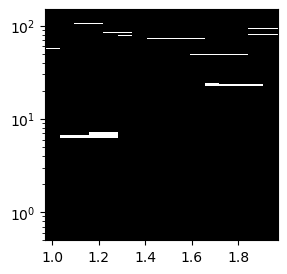

In [7]:
fig,ax = plt.subplots(1,1,figsize=(3,3))

ax.pcolormesh(sts[(sts>=1)&(sts<2)],f,D.mean(axis=2).T>np.percentile(coh_perms,97.5,axis=2).T,cmap="grey",shading="nearest",vmin=0,vmax=0.25)
ax.set_yscale("log")
ax.set_ylim([0.5,150])

193 neutral


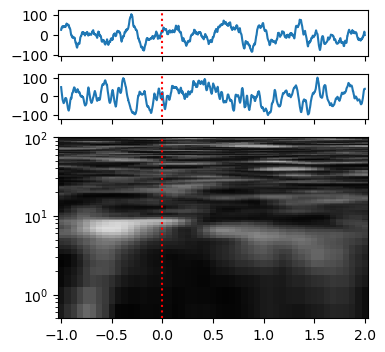

In [8]:
randix = np.random.randint(all_coh.shape[2])
print(randix,events.img_category.iloc[randix])

spect_ts = np.linspace(s_pre,s_post,spect_ixs.shape[1])
tfilt = (spect_ts>s_pre+(t_win/2)) & (spect_ts<=s_post-(t_win/2))

randspect = smoothcoh[:,:,randix]
fig,axes = plt.subplots(nrows=3,ncols=1,height_ratios=[1,1,4],
                        sharex=True,figsize=(4,4))

axes[0].plot(spect_ts[tfilt],bipolar1[spect_ixs[randix,tfilt]])
axes[1].plot(spect_ts[tfilt],bipolar2[spect_ixs[randix,tfilt]])
axes[2].pcolormesh(sts+s_pre,f,randspect.T,cmap="grey",shading="nearest",vmin=0,vmax=1)
axes[2].set_ylim([0.5,100])
axes[2].plot([0,0],axes[2].get_ylim(),"r:")
axes[2].set_yscale("log")
# axes[0].set_ylim([-1,1])
axes[0].plot([0,0],axes[0].get_ylim(),"r:")
axes[1].plot([0,0],axes[1].get_ylim(),"r:")
plt.show()

In [9]:
# calculate first spectrogram so I don't have to manually figure df and dt
f,sts,spectra = spectral.multitaper_spectrogram(bipolar1[spect_ixs[0,:]],resrate,time_step=t_res,
                                       window_length=t_win,NW=3,detrend='off',
                                       freq_range=[0.5, 150],
                                       nfft=2*t_win*resrate, db_scale=False,
                                       boundary_pad=False)
all_spect1 = np.zeros(shape=spectra.shape+(bipolar1[spect_ixs].shape[0],))
all_spect1[:,:,0] = spectra
all_spect2 = np.zeros(shape=spectra.shape+(bipolar1[spect_ixs].shape[0],))
_,_,spectra2 = spectral.multitaper_spectrogram(bipolar2[spect_ixs[0,:]],resrate,time_step=t_res,
                                      window_length=t_win,NW=3,detrend='off',
                                      freq_range=[0.5, 150],
                                      nfft=2*t_win*resrate, db_scale=False,
                                      boundary_pad=False)
all_spect2[:,:,0] = spectra2
for trial in range(1,spect_ixs.shape[0]):
    f,sts,spectra1 = spectral.multitaper_spectrogram(bipolar1[spect_ixs[trial,:]],resrate,time_step=t_res,
                                         window_length=t_win,NW=3,detrend='off',
                                         freq_range=[0.5, 150],
                                         nfft=2*t_win*resrate, db_scale=False,
                                         boundary_pad=False)
    all_spect1[:,:,trial] = spectra1

    f,sts,spectra2 = spectral.multitaper_spectrogram(bipolar2[spect_ixs[trial,:]],resrate,time_step=t_res,
                                         window_length=t_win,NW=3,detrend='off',
                                         freq_range=[0.5, 150],
                                         nfft=2*t_win*resrate, db_scale=False,
                                         boundary_pad=False)
    all_spect2[:,:,trial] = spectra2

smoothspect1 = unifilt(all_spect1, [5,3], mode="nearest", axes=[0,1])
smoothspect2 = unifilt(all_spect2, [5,3], mode="nearest", axes=[0,1])


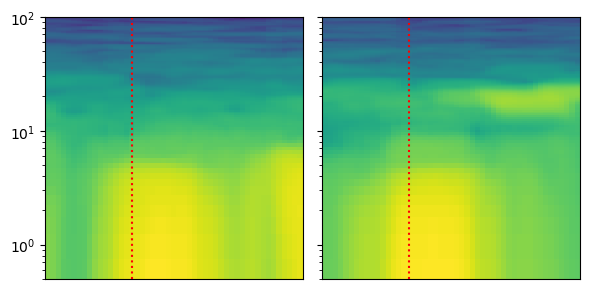

In [16]:
fig,ax = plt.subplots(1,2,figsize=(6,3),layout="tight")

randix = rng.integers(low=0,high=smoothspect1.shape[2])
ax[0].pcolormesh(sts+s_pre,f,np.log10(smoothspect1[:,:,randix]))
ax[1].pcolormesh(sts+s_pre,f,np.log10(smoothspect2[:,:,randix]))
[ax[ix].set_xticks([]) for ix in range(ax.shape[0])]
[ax[ix].set_yscale("log") for ix in range(ax.shape[0])]
[ax[ix].set_ylim([0.5,100]) for ix in range(ax.shape[0])]
[ax[ix].plot([0,0],[0.5,100],"r:") for ix in range(ax.shape[0])]
ax[1].set_yticklabels([])

plt.show()

In [11]:
# calculating PSI

Sxx = np.zeros(all_spect1.shape,dtype=np.float64)
Syy = np.zeros(Sxx.shape,dtype=np.float64)
Sxy = np.zeros(Syy.shape,dtype=np.complex128)

for trial in range(spect_ixs.shape[0]):
    f,sts,tSxx,tSyy,tSxy = spectral.multitaper_cohgram(bipolar1[spect_ixs[trial,:]],bipolar2[spect_ixs[trial,:]],
                                                    resrate,time_step=t_res,window_length=t_win,NW=3,detrend='off',
                                                    freq_range=[0.5, 150],nfft=2*t_win*resrate,boundary_pad=False,ret_spect=True)
    Sxx[:,:,trial] = tSxx.T
    Syy[:,:,trial] = tSyy.T
    Sxy[:,:,trial] = tSxy.T

Cxy = Sxy/np.sqrt(Sxx*Syy)


In [12]:
# calculate PSI for freq band
alpha0 = 6 # wide range b/c alpha is slower in younger kids
alpha1 = 12

alphaPSI = np.sum(np.imag(np.conj(Cxy[alpha0:(alpha1-1),:,:])*Cxy[(alpha0+1):alpha1,:,:]),axis=0)

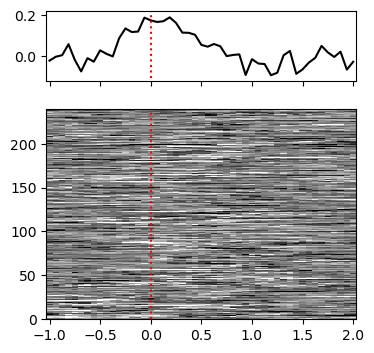

In [13]:
fig,ax = plt.subplots(2,1,height_ratios=[1,3],
                      sharex=True,figsize=(4,4))
# recommended to do jackknife (or at least boostrap) std estimate
n = 1000
randts = rng.integers(low=0,high=alphaPSI.shape[1],size=alphaPSI.shape[1]*n)
bootmat = alphaPSI[:,randts].reshape((alphaPSI.shape+(n,)))
bootstd = bootmat.std(axis=1).mean(axis=-1)
# divide avgPSI by boot-strap std
normPSI = alphaPSI.mean(axis=1)/bootstd
ax[0].plot(sts+s_pre,normPSI,"k")
ax[1].pcolormesh(sts+s_pre,np.arange(alphaPSI.shape[1]),alphaPSI.T,cmap="grey",shading="nearest",
                 vmin=np.percentile(alphaPSI.ravel(),1), vmax=np.percentile(alphaPSI.ravel(),99))
[ax[ix].plot([0,0], ax[ix].get_ylim(),"r:") for ix in range(len(ax))]
plt.show()


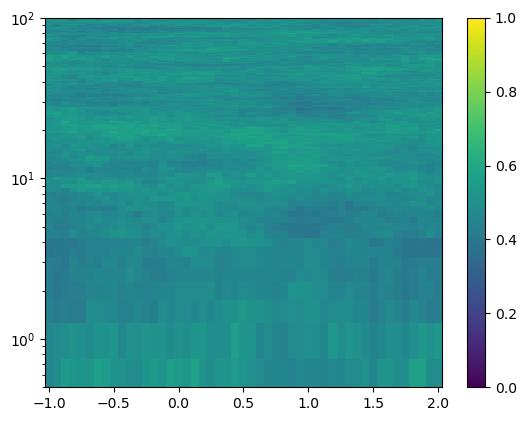

In [15]:
dpli = np.mean(np.heaviside(np.imag(Sxy), 0.5),axis=2)  # average across trials

plt.pcolormesh(sts+s_pre,f,dpli, vmin=0, vmax=1)
plt.ylim([0.5,100])
plt.yscale("log")
plt.colorbar()